In this notebook, we study Supernovae Ia (SNIa).

In [3]:
# import required packages:
import skysurvey
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import lightcurve
import lsst_functions
from lightcurve import generate_snia_lightcurve, plot_lightcurve, limit_mag_dict, get_valid_bands
from lightcurve import generate_snia_dict, generate_ordered_parameter_list, determine_visibility

# import cosmology parameters
import sncosmo
from params import p_cosmology

lsst_colors = ["tab:purple", "tab:green", "tab:orange", "tab:red", "tab:brown", "0.5"]
lsst_bands = ["lsstu", "lsstg", "lsstr", "lssti", "lsstz", "lssty"]
snia_lightcurve_params = ["z", "x1", "c", "t0", "magabs", "ra", "dec"] #note: lightcurve.py uses "redshift" 

Load LSST as opsim (to be retrieved from the website: ). Note that the filesizes can be large 
If you want to choose only one band: band IN ('g') AND night < ...

In LSST opsim, the filters have an additional suffixes e.g. _6. For ease of coding, we replace the str using regex.

In [6]:
opsim_path = "baseline_v5.3.5_10yrs.db" # provide fullpath
# opsim_path = "Surveys/baseline_v5.3.5_10yrs.db:Zone.Identifier"
lsst = skysurvey.LSST.from_opsim(opsim_path, sql_where="night < 365")

# Remove the suffix.
lsst.data["band"] = (lsst.data["band"].str.replace(r"_\d+$", "", regex=True))
lsst.data["band"].unique()

<ArrowStringArray>
['lsstu', 'lsstr', 'lsstg', 'lssti', 'lsstz', 'lssty']
Length: 6, dtype: str

In [7]:
#  llod the date range across all the nights
from astropy.time import Time
tmin, tmax = lsst.date_range
print(f"Start: {Time(tmin, format='mjd').iso}")
print(f"End:   {Time(tmax, format='mjd').iso}")
print(f"Duration: {(tmax - tmin)/365.25:.1f} years")
lsst.date_range

Start: 2026-06-17 04:52:30.000
End:   2027-06-10 01:46:52.500
Duration: 1.0 years


(np.float32(61208.203), np.float32(61566.074))

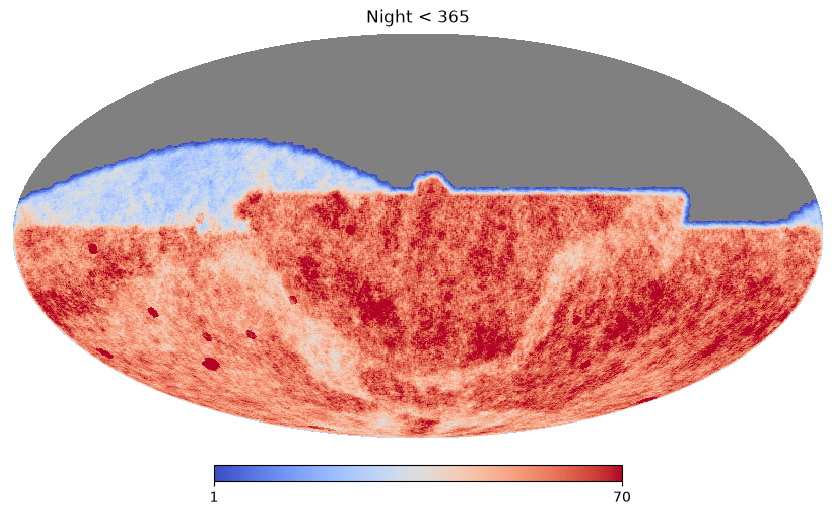

In [11]:
# uncomment the following if you want to see the field coverage for your given opsim
coverage = lsst.get_fieldcoverage()
lsst.show(vmin=0, vmax=coverage.quantile(0.95), cmap="coolwarm", title = f'Night < 365')
# lsst.data # gives all info about the observation over all the nights (e.g skynoise and in what band). Returns pandas.df

To look at observations across all filters in a given field id, use:
<code> select_fieldid = (lsst.data['fieldid'] == 336769) </code>
<code> lsst.data[select_fieldid] </code>

When generating a population, we always use these three back-to-back:
Theoretical lightcurves are simulated from phase [-20, 50], which are days w.r.t peak time. Observations of the target in that particilar field are made at later dates too (but are less likely to have SNR > 5.)

In [6]:
snia_dict = generate_snia_dict(redshift = 0.2, ra = None, dec = None, x1 = 0.0, t0 = None, magabs = -18.523, c = 0.0)
snia_param_list = generate_ordered_parameter_list(input_dict = True, params = snia_dict)
snia_models, data_models = generate_snia_lightcurve(*snia_param_list, bands = lsst_bands, in_mag = False, N_tot = 100, tstart = tmin, tstop = tmax, zp=30, plot_curve = False, return_values = True, return_models = True, verbose = False)

CUSTOM MODEL IS {'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x75ea85d30b40>, 'kwargs': {'dec_range': [-90, 0]}}, 'redshift': {'func': <function fixed_param at 0x75eb10d77270>, 'kwargs': {'size': 100, 'value': 0.2}, 'as': 'z'}, 'x1': {'func': <function fixed_param at 0x75eb10d77270>, 'kwargs': {'size': 100, 'value': 0.0}, 'as': 'x1'}, 'c': {'func': <function fixed_param at 0x75eb10d77270>, 'kwargs': {'size': 100, 'value': 0.0}, 'as': 'c'}, 'magabs': {'func': <function fixed_param at 0x75eb10d77270>, 'kwargs': {'size': 100, 'value': -18.523}, 'as': 'magabs'}}


Essential functions:

skysurvey.Target.core.data.loc[index]
- To see a pd.Series of the data specific target transient of a particular index, use .loc[index]. (Note: using .iloc[5] will give the 5th target regardless of index number)

plot_lightcurve() (from <code>lightcurve.py</code>)
- uses the lightcurve times + flux values to plot theoretical lightcurves for a given object. Useful for comparing with theoretical flux/mag limits.

Once you simulated N_tot supernovae, the <code> .from_targets_and_survey() </code> function simulates the observation plan and sees if our SN are visible.

Functions:

- <code>skysurvey.dataset.get_target_lightcurve(self, index, detection=None, phase_range=None)</code> gives a dataframe of diff index_obs with columns: field params.
- <code>skysurvey.dataset.get_data</code> gives a dataframe of obs of a particular index. You can filter depending on <code>detection = bool or None.</code>
- <code>lightcurve.show_target_lightcurve()</code>: Shows theoretical lightcurve of one index + simulated observations from skysurvey.

In [12]:
snia_dict = generate_snia_dict(redshift = None, ra = None, dec = None, x1 = None, t0 = None, magabs = None, c = None)
snia_param_list = generate_ordered_parameter_list(input_dict = True, params = snia_dict)

In [97]:
# if you changed the lsst_functions.py file but do not want to restart the kerne;
import importlib
importlib.reload(lsst_functions)

<module 'lsst_functions' from '/home/denzelgoh/TransientSimulation/lsst_functions.py'>

In [98]:
# import our detection functions from lsst_functions.py

# function that filters out sources based on selection criteria
from lsst_functions import five_sigma_detection_multiband

# functions for number of sources detected
from lsst_functions import detectability_sources # to return a summary of detected sources.

# functions for number of alerts predicted
from lsst_functions import get_number_detections_allbands, n_detections_sources, get_total_alerts_from_survey # this is for if you want to loop through several redshifts. It stores for every redshift.


### Filtering observations

Here, we choose a common selection criteria of 5 total dets, min. 2 dets in 2 bands

In [99]:
# set the N_tot and selection criteria. (5, 2, 2) is the default.
N_tot = 1000

from lsst_functions import set_selection_criteria
selection_criteria = set_selection_criteria(total_points=5, n_filters=2, min_points_per_filter=2)

In [53]:
detected = get_total_alerts_from_survey(snia_param_list = snia_param_list, opsim = lsst, N_tot = N_tot, selection_criteria = selection_criteria)

Start: 2026-06-17 04:52:30.000
End:   2027-06-10 01:46:52.500
Duration: 1.0 years
All params input as None. Using default sampling functions, but with p_cosmology.
CUSTOM MODEL IS {'redshift': {'func': <function sample_redshift_from_Rz at 0x791b17799220>, 'kwargs': {'N': 1000, 'R_z': <function R_SFR at 0x791bc01d6fb0>, 'z_max': 1.0, 'p_cosmology': {'c': 299792.458, 'h0': 67.4, 'omega_M': 0.315, 'omega_K': 0, 'omega_L': 0.685, 'z_min': 0.0001, 'N_int_steps': 100, 'R0': {'SN Ia': <Quantity 23000. 1 / (yr Gpc3)>, 'SN CC': <Quantity 101000. 1 / (yr Gpc3)>, 'SN Ibc': <Quantity 101000. 1 / (yr Gpc3)>, 'SN II': <Quantity 101000. 1 / (yr Gpc3)>, 'TDE': <Quantity 8.e-07 1 / (yr Mpc3)>, 'KN': <Quantity 59.3 1 / (yr Gpc3)>}}}, 'as': 'z'}, 'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x791b1f904d50>, 'kwargs': {'dec_range': [-90, 0]}}}


100%|██████████| 1000/1000 [00:26<00:00, 37.28it/s]


In [54]:
detected

,target,z,ra,dec,t0,detected,n_detections
0,0,0.637563,291.314972,-18.717270,61440.980469,False,0
1,1,0.413343,36.768787,-32.187431,61490.496094,False,0
2,2,0.430781,237.439255,-0.510577,61225.203125,True,6
3,3,0.805807,214.347961,-59.218273,61257.320312,False,0
4,4,0.394355,67.373337,-62.573044,61471.769531,False,0
...,...,...,...,...,...,...,...
995,995,0.167465,55.372765,-9.948995,61392.589844,True,13
996,996,0.517843,128.050018,-23.630953,61281.531250,False,0
997,997,0.715646,325.524658,-18.253996,61451.863281,False,0
998,998,0.991801,31.897120,-20.047499,61518.625000,False,0


In [90]:
# add a column stating which redshift bin to be included in (for histogram purposes)
z_bins = np.arange(0, 1.01, 0.1) # set z bins
detected["z_bin"] = pd.cut(detected["z"],bins=z_bins,right=False)
detected[(detected['detected'] == True) & (detected['n_detections'] < 6)]

,target,z,ra,dec,t0,detected,n_detections,z_bin
38,38,0.280195,25.815048,-46.855446,61430.089844,True,5,"[0.2, 0.3)"
101,101,0.777340,338.067078,-14.457424,61249.710938,True,5,"[0.7, 0.8)"
112,112,0.776960,312.048279,-14.913550,61298.554688,True,5,"[0.7, 0.8)"
208,208,0.489286,140.275589,-21.550217,61393.906250,True,5,"[0.4, 0.5)"
236,236,0.452189,323.469421,-34.332508,61535.187500,True,5,"[0.4, 0.5)"
237,237,0.298023,222.488693,-3.673886,61250.660156,True,5,"[0.2, 0.3)"
395,395,0.574588,147.125580,-4.683903,61545.488281,True,5,"[0.5, 0.6)"
480,480,0.462548,266.573273,-21.972399,61233.667969,True,5,"[0.4, 0.5)"
509,509,0.481057,280.649994,-38.133614,61559.617188,True,5,"[0.4, 0.5)"
532,532,0.393565,236.497543,-41.014519,61224.617188,True,5,"[0.3, 0.4)"


In [ ]:
detected_sources = detected[detected["detected"]]
n_sources = (detected_sources.groupby("z_bin", observed=True).size())
n_points = (detected_sources.groupby("z_bin", observed=True)["n_detections"].sum())

# print(n_sources)
print(n_points)

z_bin
[0.0, 0.1)    216
[0.1, 0.2)    447
[0.2, 0.3)    415
[0.3, 0.4)    417
[0.4, 0.5)    138
[0.5, 0.6)    243
[0.6, 0.7)     83
[0.7, 0.8)     30
[0.9, 1.0)      7
Name: n_detections, dtype: int64


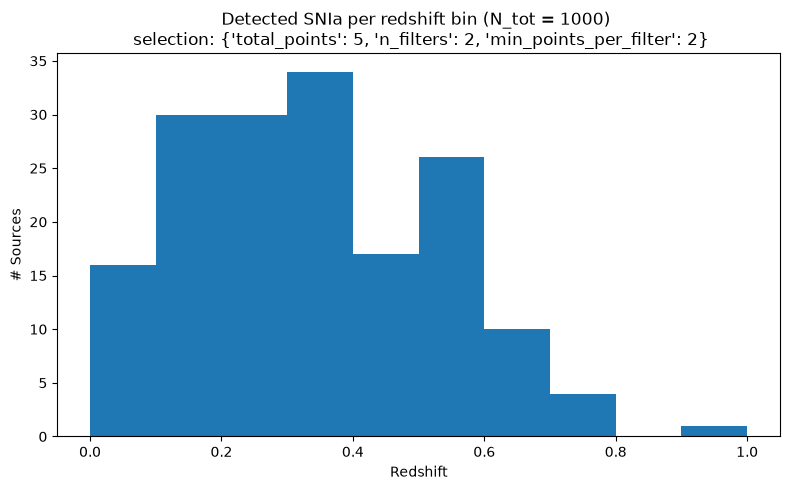

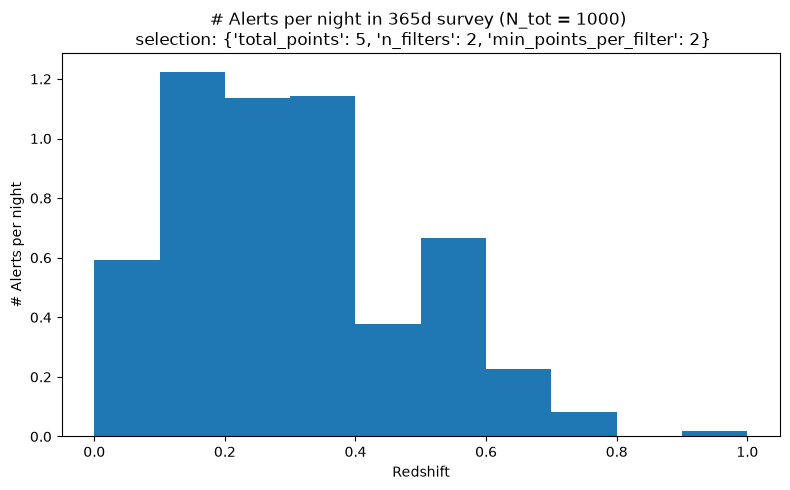

In [ ]:


plt.figure(figsize=(8, 5))

plt.hist(detected_sources["z"],bins=z_bins)

plt.xlabel("Redshift")
plt.ylabel("# Sources")
plt.title(f"Detected SNIa per redshift bin (N_tot = {N_tot}) \n selection: {selection_criteria}")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(detected_sources['z'], weights = detected_sources["n_detections"]/365, bins=z_bins)

plt.xlabel("Redshift")
plt.ylabel("# Alerts per night")
plt.title(f"# Alerts per night in 365d survey (N_tot = {N_tot}) \n selection: {selection_criteria}")

plt.tight_layout()
plt.show()

In [82]:
detected = detected.drop(columns = ['z_bin'])


In [83]:
detected

,target,z,ra,dec,t0,detected,n_detections
0,0,0.637563,291.314972,-18.717270,61440.980469,False,0
1,1,0.413343,36.768787,-32.187431,61490.496094,False,0
2,2,0.430781,237.439255,-0.510577,61225.203125,True,6
3,3,0.805807,214.347961,-59.218273,61257.320312,False,0
4,4,0.394355,67.373337,-62.573044,61471.769531,False,0
...,...,...,...,...,...,...,...
995,995,0.167465,55.372765,-9.948995,61392.589844,True,13
996,996,0.517843,128.050018,-23.630953,61281.531250,False,0
997,997,0.715646,325.524658,-18.253996,61451.863281,False,0
998,998,0.991801,31.897120,-20.047499,61518.625000,False,0


In [ ]:
# save to parquet
detected.to_parquet(
    "smallparquet.parquet",
    engine="pyarrow",
    compression="zstd",
    index=False
)

In [95]:
example = pd.read_parquet('SNParquets/test_parquet.parquet')
example

,target,z,ra,dec,t0,detected,n_detections
0,0,0.391595,137.598007,-27.899683,61451.925781,True,16
1,1,0.628783,291.860168,-0.813505,61426.632812,False,0
2,2,0.573308,248.084091,-81.774208,61449.066406,False,0
3,3,0.285084,271.158142,-14.354739,61192.343750,True,7
4,4,0.692918,328.366333,-1.830170,61162.875000,False,0
...,...,...,...,...,...,...,...
9995,9995,0.196232,84.348785,-15.727390,61270.667969,False,0
9996,9996,0.205392,172.949387,-51.370121,61555.171875,False,0
9997,9997,0.614645,15.414575,-45.277348,61403.656250,False,0
9998,9998,0.994361,224.058289,-9.600336,61220.714844,False,0


KeyError: 'x1'

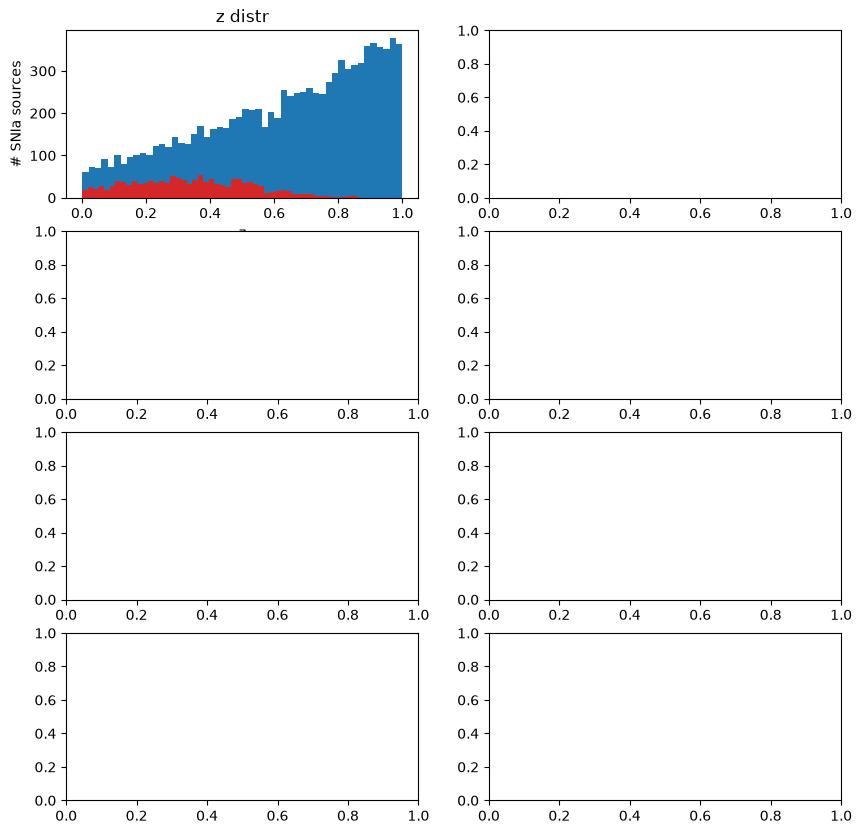

In [96]:
#perhaps this way, you don't need to specify bins?

detected_models = example[example['detected'] == True] # a df

params = ['z', 'x1', 'c', 't0', 'magabs', 'magobs', 'ra', 'dec']

fig, axs = plt.subplots(4, 2, figsize=(10, 10))

for ax, param in zip(axs.flat, params):
    ax.hist(example[param], bins=50, color = 'tab:blue')
    ax.hist(detected_models[param], bins=50, color = 'tab:red')
    if param == 't0':
        ax.axvline(tmin, color = 'k', linestyle = '--', label = 'obs tmin')
        ax.legend()
    ax.set_xlabel(param)
    ax.set_ylabel("# SNIa sources")
    ax.set_title(f"{param} distr")

# Hide unused subplot
for ax in axs.flat[len(params):]:
    ax.set_visible(False)
plt.suptitle(f'N_tot = {N_tot} SNIa | detected sources = {len(detected_models)} | night < 365 | all randomised parameters')
plt.tight_layout()

plt.show()